# Extended Wigner's friend scenario (with GHZ friends)

The extended Wigner's friend scenario (EWFS) with GHZ friends. Consider both "random" and "majority vote" approaches. Only consider the semi-Brukner inequality.

## Imports and setup

In [10]:
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_distribution, plot_histogram

from ewfs import EWFS, decode_results, MAJORITY_VOTE, post_select_results
from ewfs.setting import PEEK, REVERSE_1, REVERSE_2
from ewfs.noise_models import depolarizing_model

## Sanity checks (for majority vote approach)

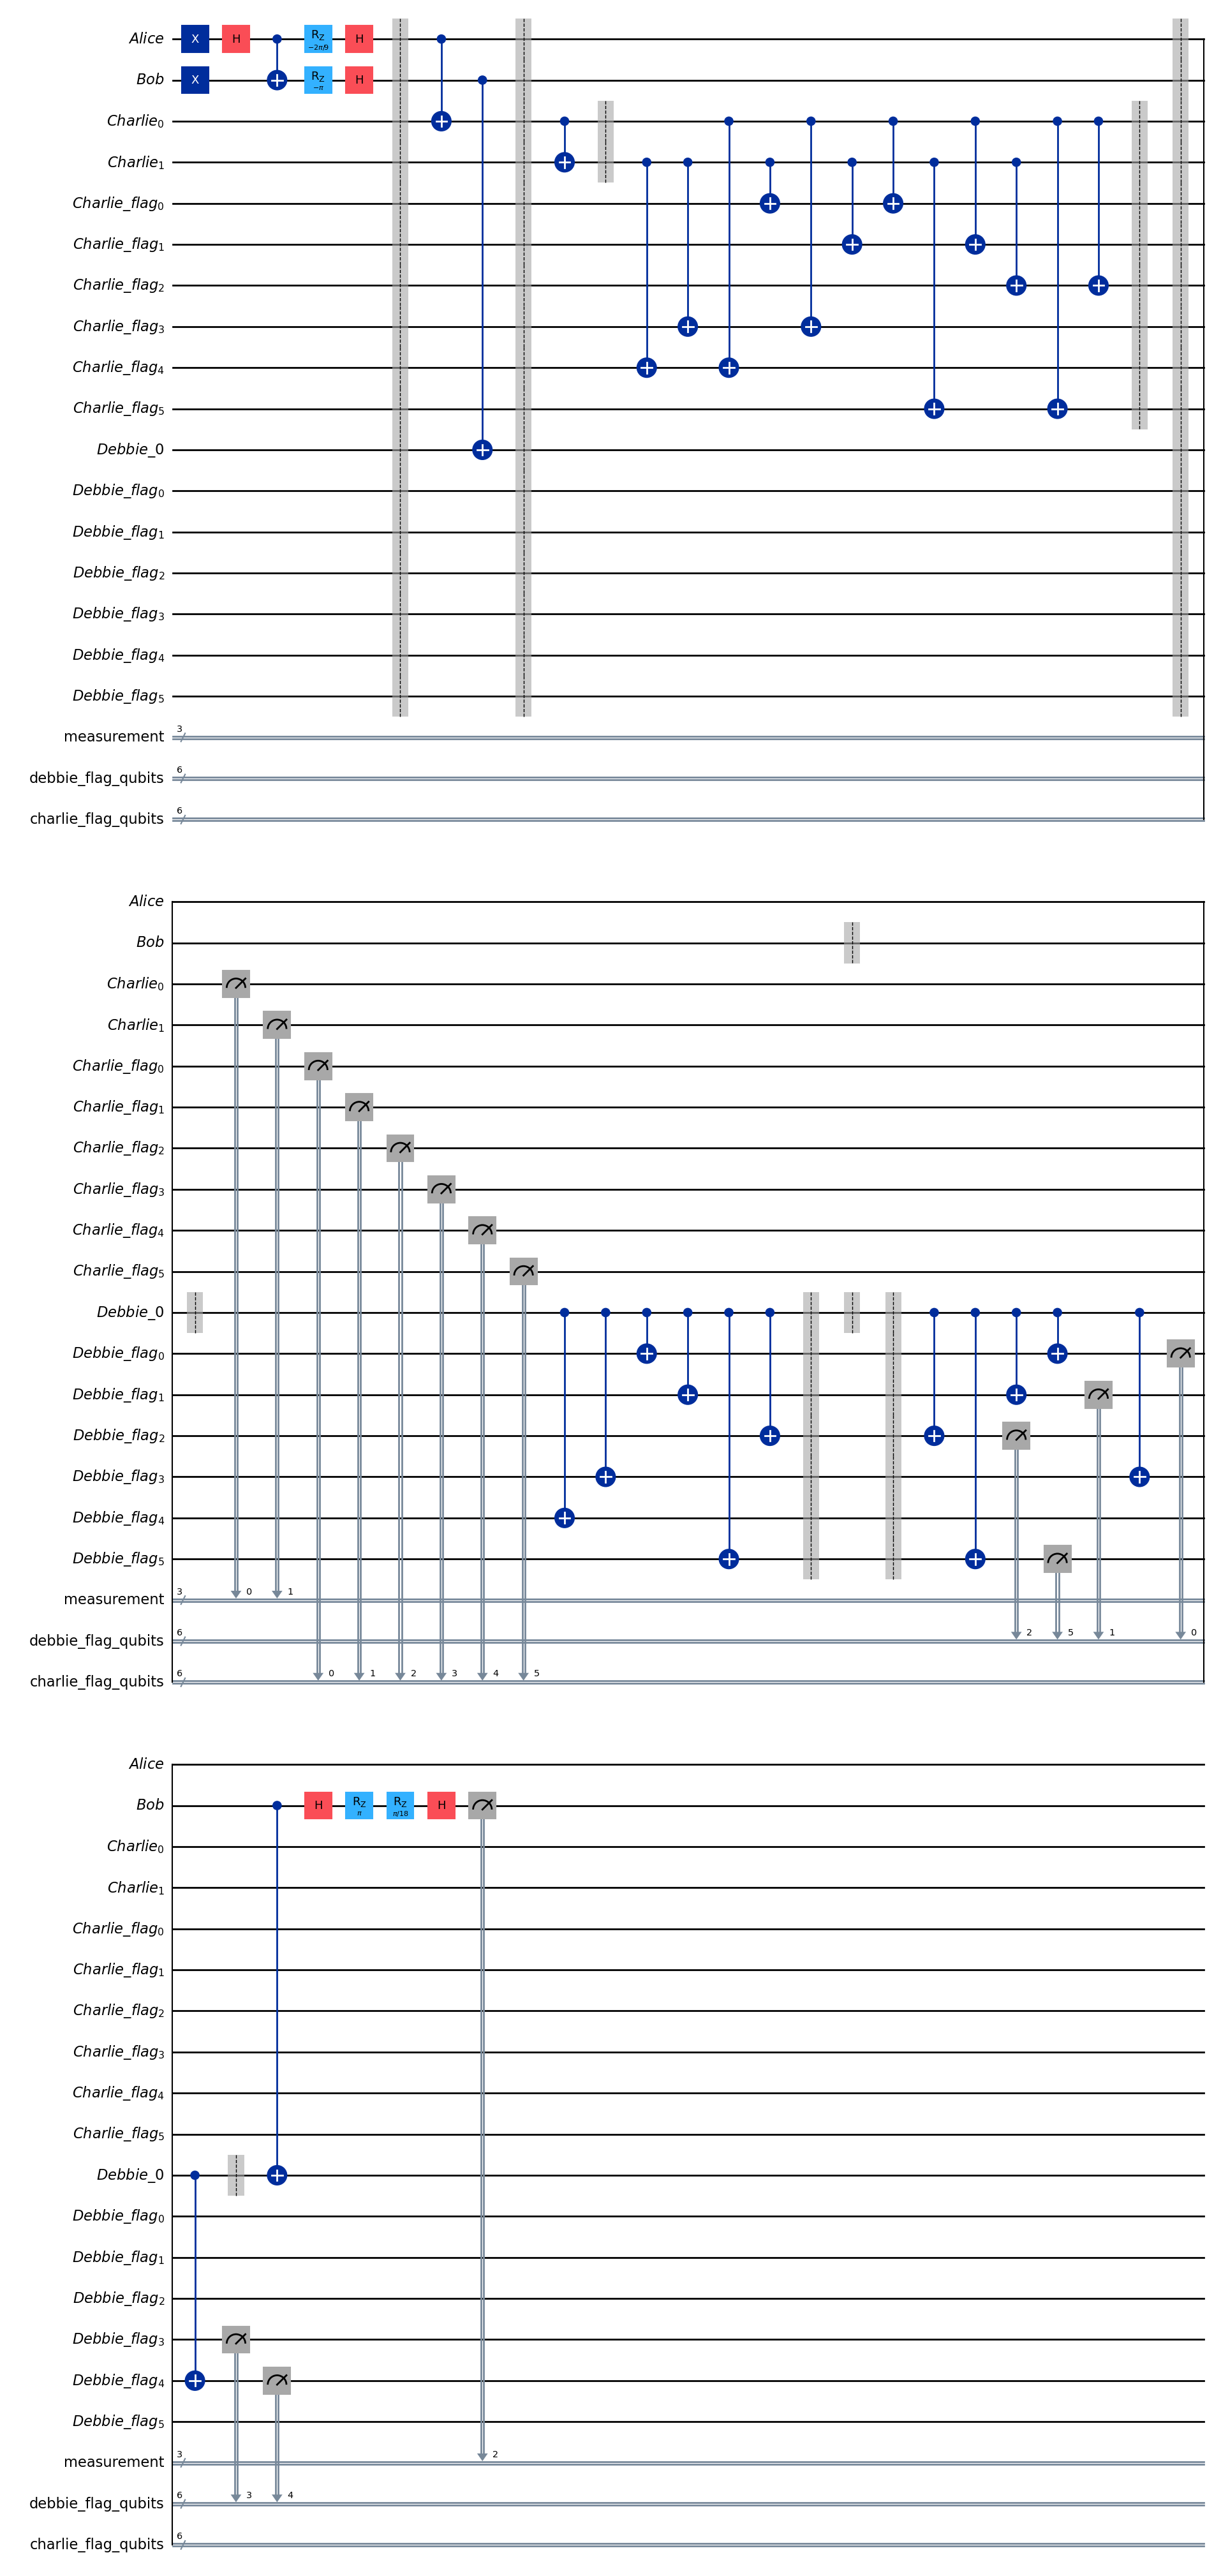

In [11]:
alice_setting = PEEK
bob_setting = REVERSE_1
charlie_size = 2
debbie_size = 1
strategy = MAJORITY_VOTE

ewfs = EWFS(
    alice_setting=alice_setting,
    bob_setting=bob_setting,
    strategy=strategy,
    charlie_size=charlie_size,
    debbie_size=debbie_size,
    friend_state="ghz",
)
qc = ewfs.circuit()
qc.draw("mpl", style="default")

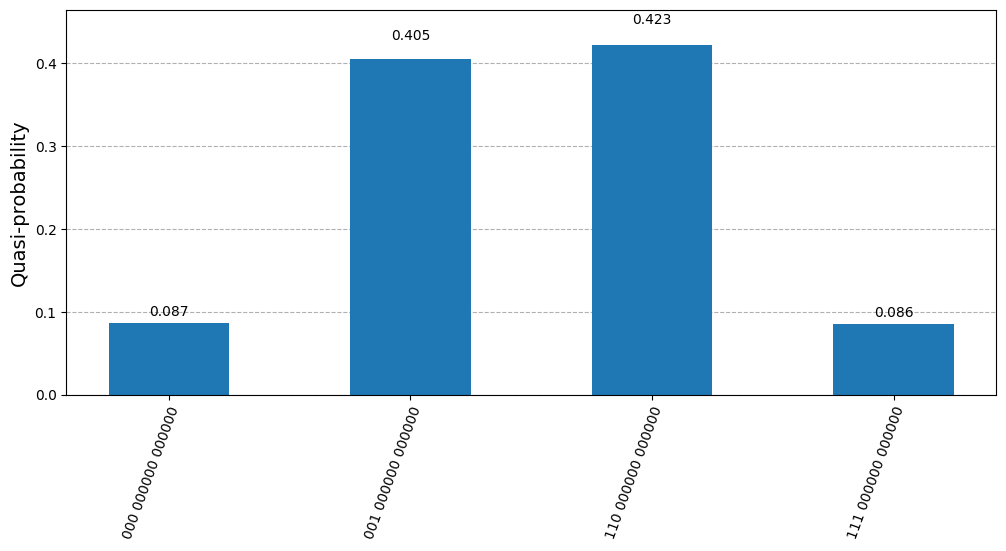

In [12]:
# lots of noise
noise_model = depolarizing_model(circ=qc, single_qubit_error_rate=0.001, two_qubit_error_rate=0.01, meas_error_rate=0.01)
# Create noisy simulator backend
sim_noise = AerSimulator(noise_model=None)

shots = 10_000
job = sim_noise.run(qc, shots=shots)
result = job.result()

counts = result.get_counts()
probabilities = {key[::-1]: value / shots for key, value in counts.items()}

plot_histogram(probabilities, figsize=(12, 5))

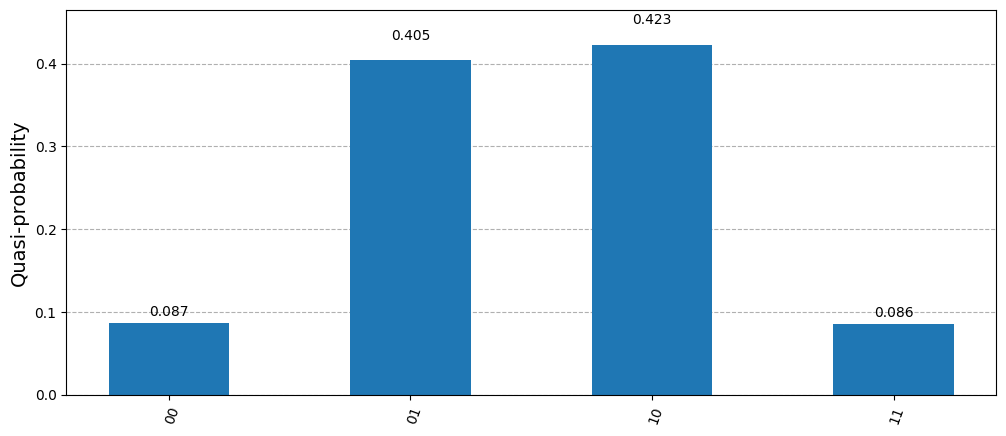

In [13]:
results = {(alice_setting, bob_setting): probabilities}
post_selected_results = post_select_results(results, charlie_size, debbie_size, 6, 6)
dec_res = decode_results(post_selected_results, charlie_size=charlie_size, debbie_size=debbie_size)
probs = dec_res[(alice_setting, bob_setting)]
plot_distribution(probs, figsize=(12, 5))

In [14]:
results

{('peek', 'reverse_1'): {'111 000000 000000': 0.0857,
  '001 000000 000000': 0.4048,
  '000 000000 000000': 0.0868,
  '110 000000 000000': 0.4227}}

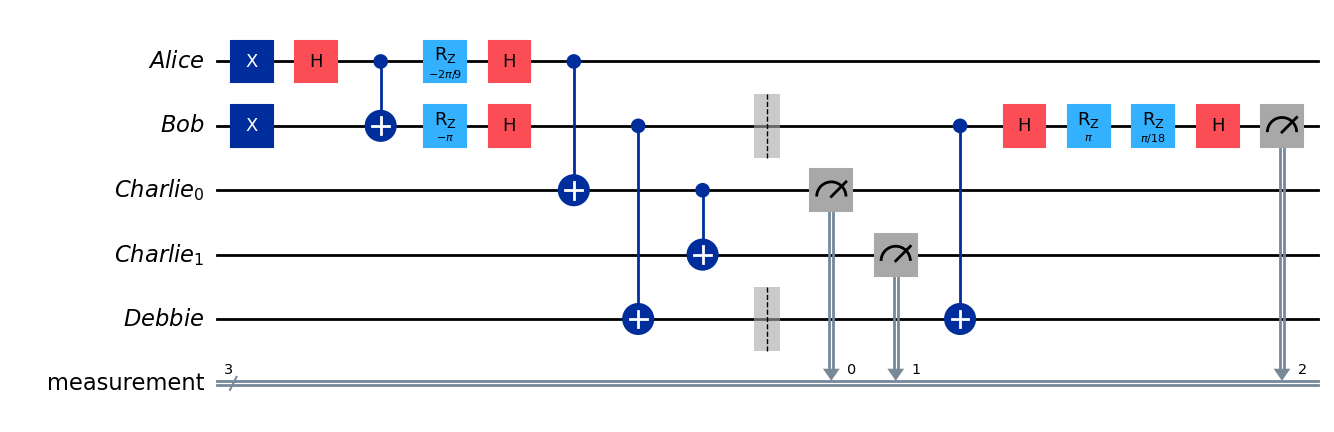

In [ ]:
# Now using the cnot_ladder approach
ewfs = EWFS(
    alice_setting=alice_setting,
    bob_setting=bob_setting,
    strategy=strategy,
    charlie_size=charlie_size,
    debbie_size=debbie_size,
    friend_state="cnot_ladder",
)
qc = ewfs.circuit()
qc.draw("mpl", style="default")

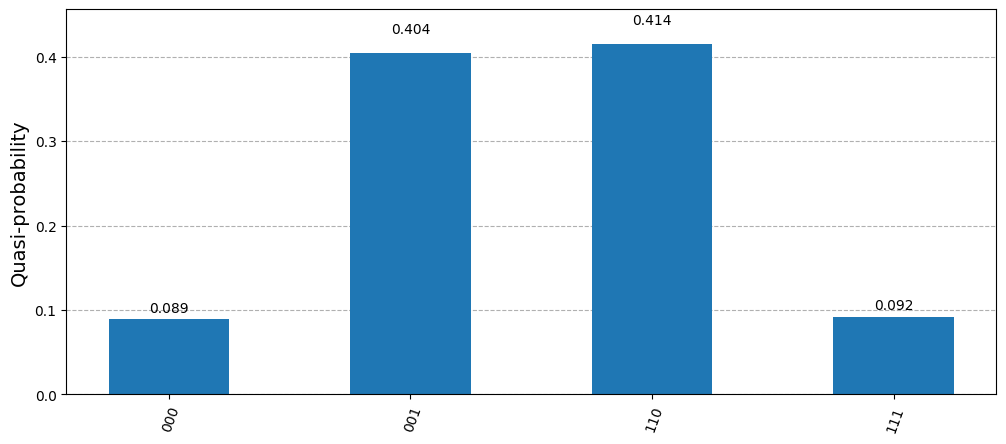

In [20]:
# Create noisy simulator backend
sim_noise = AerSimulator(noise_model=None)

shots = 10_000
job = sim_noise.run(qc, shots=shots)
result = job.result()

counts = result.get_counts()
probabilities = {key[::-1]: value / shots for key, value in counts.items()}

plot_histogram(probabilities, figsize=(12, 5))

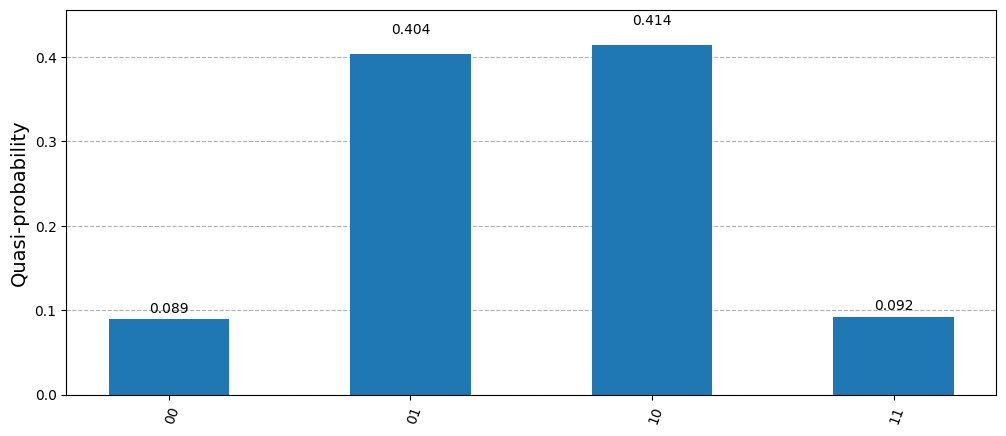

In [21]:
results = {(alice_setting, bob_setting): probabilities}
dec_res = decode_results(results, charlie_size=charlie_size, debbie_size=debbie_size)
probs = dec_res[(alice_setting, bob_setting)]
plot_distribution(probs, figsize=(12, 5))

## Experiment

Run EWFS experiment for a specific number of shots, trials, and over a range of friend sizes.

#### Settings

In [18]:
from ewfs import run_experiment, SEMI_BRUKNER_SETTINGS

run_experiment(settings=SEMI_BRUKNER_SETTINGS, strategy="random")

Trial 1 out of 2 for task of 1_1
Task with task ID: 5fd957c6-0225-48f5-b946-20228f2b8612

Trial 2 out of 2 for task of 1_1
Task with task ID: f0162c83-845c-4e85-ba60-0a489f51b9c5

Trial 1 out of 2 for task of 2_1
Task with task ID: 1469d7eb-4d92-4ae1-88c0-c118578e7197

Trial 2 out of 2 for task of 2_1
Task with task ID: 01ad0700-2d35-49c7-830c-b2c540ae032b

Processing trial 1 for task with task ID: 5fd957c6-0225-48f5-b946-20228f2b8612
Results: {('peek', 'reverse_1'): {'10': 0.4077, '11': 0.0917, '01': 0.4094, '00': 0.0912}, ('peek', 'reverse_2'): {'11': 0.4041, '00': 0.4189, '01': 0.0885, '10': 0.0885}, ('reverse_2', 'reverse_1'): {'10': 0.4453, '01': 0.4387, '00': 0.0605, '11': 0.0555}, ('reverse_2', 'reverse_2'): {'10': 0.4437, '01': 0.4391, '11': 0.0581, '00': 0.0591}}
semi_brukner=0.8138000000000001 -- is violated: True
Violations: {'semi_brukner': 0.8138000000000001}

Post-processed results: defaultdict(<function run_experiment.<locals>.<lambda> at 0x12f287b00>, {'1_1': defaultdic

defaultdict(<function ewfs.experiment.run_experiment.<locals>.<lambda>()>,
            {'1_1': defaultdict(list,
                         {'semi_brukner': [0.8138000000000001,
                           0.8048000000000002]}),
             '2_1': defaultdict(list,
                         {'semi_brukner': [0.8173999999999997,
                           0.8071999999999999]})})